In [6]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
from faster_whisper import WhisperModel
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [7]:
TRAIN_AUDIO = r"D:\Tarun Lakhani\Job exam\dataset\audios\train"
TEST_AUDIO  = r"D:\Tarun Lakhani\Job exam\dataset\audios\test"
TRAIN_CSV   = r"D:\Tarun Lakhani\Job exam\dataset\csvs\train.csv"
OUTPUT_CSV  = r"D:\Tarun Lakhani\Job exam\dataset\predictions.csv"
MODEL_PATH  = r"D:\Tarun Lakhani\Job exam\dataset\simple_model.pkl"

In [8]:
df_train = pd.read_csv(TRAIN_CSV)
print("Training Data Shape:", df_train.shape)
print("\nFirst 5 rows:")
display(df_train.head())
print("\nLabel Distribution:")
print(df_train["label"].value_counts().sort_index())

Training Data Shape: (409, 2)

First 5 rows:


,filename,label
0,audio_173,3.0
1,audio_138,3.0
2,audio_127,2.0
3,audio_95,2.0
4,audio_73,3.5



Label Distribution:
1.0      1
1.5      1
2.0     90
2.5     72
3.0    154
3.5     46
4.0     15
4.5     10
5.0     20
Name: label, dtype: int64


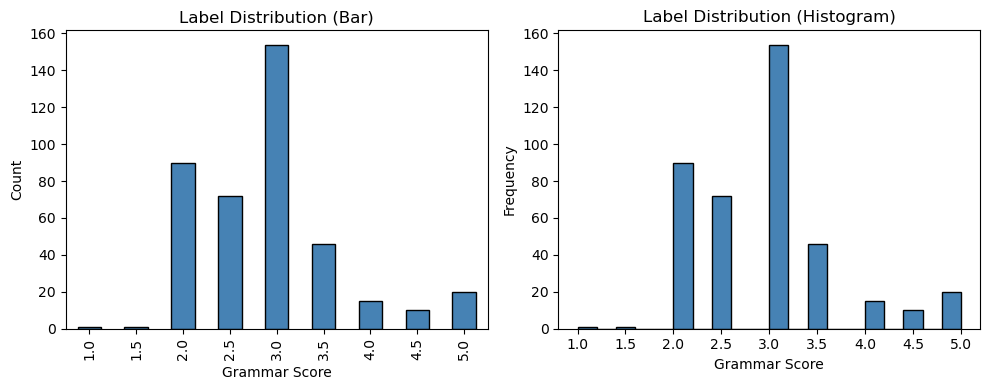

Mean score: 2.910757946210269
Std score: 0.7669532686326861


In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df_train["label"].value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Label Distribution (Bar)")
plt.xlabel("Grammar Score")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
df_train["label"].plot(kind="hist", bins=20, color="steelblue", edgecolor="black")
plt.title("Label Distribution (Histogram)")
plt.xlabel("Grammar Score")

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()
print("Mean score:", df_train["label"].mean())
print("Std score:",  df_train["label"].std())

In [10]:
print("Loading Whisper model...")
whisper_model = WhisperModel("tiny", device="cpu", compute_type="int8")
print("Whisper model loaded.")

Loading Whisper model...
Whisper model loaded.


In [53]:
def transcribe(file_path):
    try:
        segments, _ = whisper_model.transcribe(file_path, beam_size=1)
        text = " ".join([seg.text for seg in segments])
        return text.strip()
    except Exception as e:
        print(f"  Transcription error: {e}")
        return ""

def get_text_features(text):
    if not text or len(text.strip()) == 0:
        return np.zeros(10, dtype=np.float32)

    words = text.split()
    word_count     = len(words)
    avg_word_len   = np.mean([len(w) for w in words]) if words else 0.0
    unique_words   = len(set(words))
    vocab_richness = unique_words / word_count if word_count > 0 else 0.0

    sentences        = [s.strip() for s in text.split(".") if s.strip()]
    sentence_count   = len(sentences)
    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0.0

    filler_words = ["um", "uh", "like", "you know", "basically", "actually", "literally", "so", "right"]
    filler_count = sum(text.lower().count(f) for f in filler_words)

    capital_errors  = sum(1 for s in sentences if s and not s[0].isupper())
    long_words      = sum(1 for w in words if len(w) > 7)
    long_word_ratio = long_words / word_count if word_count > 0 else 0.0

    return np.array([
        word_count, avg_word_len, unique_words, vocab_richness,
        sentence_count, avg_sentence_len, filler_count,
        capital_errors, long_words, long_word_ratio
    ], dtype=np.float32)

def get_audio_features(file_path):
    y, sr_rate = librosa.load(file_path, sr=16000)

    mfcc            = librosa.feature.mfcc(y=y, sr=sr_rate, n_mfcc=13)
    mfcc_mean       = np.mean(mfcc, axis=1)
    mfcc_std        = np.std(mfcc, axis=1)
    mfcc_delta      = librosa.feature.delta(mfcc)
    mfcc_delta_mean = np.mean(mfcc_delta, axis=1)
    mfcc_delta_std  = np.std(mfcc_delta, axis=1)

    pitches, _ = librosa.piptrack(y=y, sr=sr_rate)
    pitch_vals = pitches[pitches > 0]
    pitch_mean = np.mean(pitch_vals) if len(pitch_vals) > 0 else 0.0
    pitch_std  = np.std(pitch_vals)  if len(pitch_vals) > 0 else 0.0

    rms      = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)
    rms_std  = np.std(rms)

    zcr      = librosa.feature.zero_crossing_rate(y)
    zcr_mean = np.mean(zcr)
    zcr_std  = np.std(zcr)

    spec_centroid  = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr_rate))
    spec_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr_rate))
    spec_rolloff   = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr_rate))
    spec_contrast  = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr_rate))

    chroma      = librosa.feature.chroma_stft(y=y, sr=sr_rate)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std  = np.std(chroma, axis=1)

    tempo, _ = librosa.beat.beat_track(y=y, sr=sr_rate)
    duration = librosa.get_duration(y=y, sr=sr_rate)
    silence  = np.sum(np.abs(y) < 0.01)  / len(y)

    return np.hstack([
        mfcc_mean, mfcc_std, mfcc_delta_mean, mfcc_delta_std,
        pitch_mean, pitch_std, rms_mean, rms_std,
        zcr_mean, zcr_std, spec_centroid, spec_bandwidth,
        spec_rolloff, spec_contrast, chroma_mean, chroma_std,
        tempo, duration, silence
    ]).astype(np.float32)

def get_features(file_path):
    audio_feats = get_audio_features(file_path)
    text        = transcribe(file_path)
    text_feats  = get_text_features(text)
    return np.hstack([audio_feats, text_feats])

print("Feature extraction functions defined.")

Feature extraction functions defined.


In [54]:
def load_training_data(audio_folder, csv_path):
    df = pd.read_csv(csv_path)
    X, y = [], []

    for _, row in df.iterrows():
        filename = str(row["filename"]).strip()
        label    = row["label"]

        if pd.isna(label):
            continue
        if not filename.endswith(".wav"):
            filename += ".wav"

        path = os.path.join(audio_folder, filename)
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue

        print(f"Processing: {filename}")
        try:
            feats = get_features(path)
            X.append(feats)
            y.append(float(label))
        except Exception as e:
            print(f"  Error: {e}")

    print(f"\nLoaded {len(X)} samples.")
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = load_training_data(TRAIN_AUDIO, TRAIN_CSV)
print(f"Feature shape: {X_all.shape}")

Processing: audio_173.wav
Processing: audio_138.wav
Processing: audio_127.wav
Processing: audio_95.wav
Processing: audio_73.wav
Processing: audio_34.wav
Processing: audio_120_2.wav
Processing: audio_224.wav
Processing: audio_342.wav
Processing: audio_228.wav
Processing: audio_133.wav
Processing: audio_223.wav
Processing: audio_287.wav
Processing: audio_332.wav
Processing: audio_158.wav
Processing: audio_91.wav
Processing: audio_358.wav
Processing: audio_79.wav
Processing: audio_10.wav
Processing: audio_78.wav
Processing: audio_313.wav
Processing: audio_239.wav
Processing: audio_31.wav
Processing: audio_74.wav
Processing: audio_204.wav
Processing: audio_57.wav
Processing: audio_369.wav
Processing: audio_194.wav
Processing: audio_282.wav
Processing: audio_105.wav
Processing: audio_138_2.wav
Processing: audio_212.wav
Processing: audio_230.wav
Processing: audio_16.wav
Processing: audio_249.wav
Processing: audio_1.wav
Processing: audio_303.wav
Processing: audio_317.wav
Processing: audio_111

In [55]:
def round_to_half(arr):
    return (np.array(arr) * 2).round() / 2

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

model = RandomForestRegressor(n_estimators=500, min_samples_leaf=1, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

val_preds         = model.predict(X_val)
val_preds_rounded = round_to_half(val_preds)
y_val_rounded     = round_to_half(y_val)

rmse_raw        = np.sqrt(mean_squared_error(y_val, val_preds))
rmse_rounded    = np.sqrt(mean_squared_error(y_val_rounded, val_preds_rounded))
corr_raw, _     = pearsonr(y_val, val_preds)
corr_rounded, _ = pearsonr(y_val_rounded, val_preds_rounded)

print(f"\n========== Validation Results (20%) ==========")
print(f"Raw     -> RMSE: {rmse_raw:.4f} | Pearson: {corr_raw:.4f}")
print(f"Rounded -> RMSE: {rmse_rounded:.4f} | Pearson: {corr_rounded:.4f}")

Train: 327 | Val: 82

========== Validation Results (20%) ==========
Raw     -> RMSE: 0.6220 | Pearson: 0.6066
Rounded -> RMSE: 0.6368 | Pearson: 0.5817


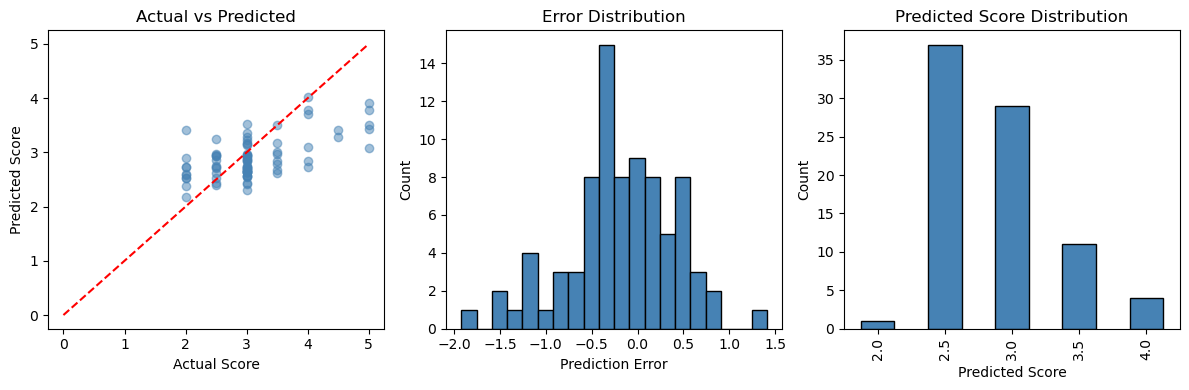

In [56]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(y_val, val_preds, alpha=0.5, color="steelblue")
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")

plt.subplot(1, 3, 2)
errors = val_preds - y_val
plt.hist(errors, bins=20, color="steelblue", edgecolor="black")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Error Distribution")

plt.subplot(1, 3, 3)
pd.Series(val_preds_rounded).value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor="black")
plt.xlabel("Predicted Score")
plt.ylabel("Count")
plt.title("Predicted Score Distribution")

plt.tight_layout()
plt.savefig("validation_results.png", dpi=150)
plt.show()

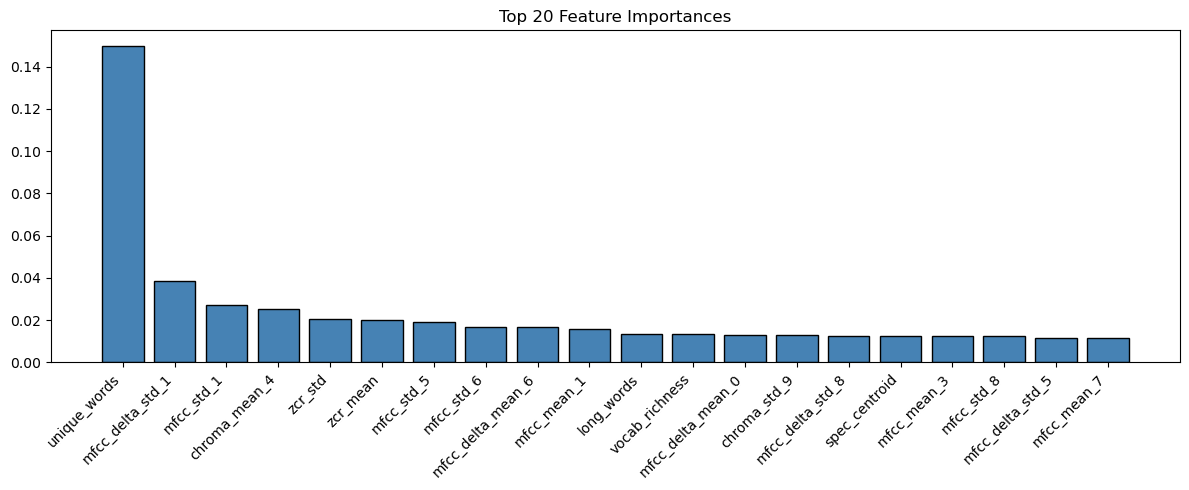

In [57]:
feature_names = (
    [f"mfcc_mean_{i}" for i in range(13)] +
    [f"mfcc_std_{i}"  for i in range(13)] +
    [f"mfcc_delta_mean_{i}" for i in range(13)] +
    [f"mfcc_delta_std_{i}"  for i in range(13)] +
    ["pitch_mean", "pitch_std", "rms_mean", "rms_std",
     "zcr_mean", "zcr_std", "spec_centroid", "spec_bandwidth",
     "spec_rolloff", "spec_contrast"] +
    [f"chroma_mean_{i}" for i in range(12)] +
    [f"chroma_std_{i}"  for i in range(12)] +
    ["tempo", "duration", "silence"] +
    ["word_count", "avg_word_len", "unique_words", "vocab_richness",
     "sentence_count", "avg_sentence_len", "filler_count",
     "capital_errors", "long_words", "long_word_ratio"]
)

importances = model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 5))
plt.bar(range(20), importances[top_idx], color="steelblue", edgecolor="black")
plt.xticks(range(20), [feature_names[i] for i in top_idx], rotation=45, ha="right")
plt.title("Top 20 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [11]:
model.fit(X_all, y_all)

train_preds   = model.predict(X_all)
train_rmse    = np.sqrt(mean_squared_error(y_all, train_preds))
train_corr, _ = pearsonr(y_all, train_preds)

print(f"========== Training Results ==========")
print(f"Training RMSE:    {train_rmse:.4f}")
print(f"Training Pearson: {train_corr:.4f}")

joblib.dump(model, MODEL_PATH)
print(f"\nModel saved to {MODEL_PATH}")

========== Training Results ==========
Training RMSE:    0.2438
Training Pearson: 0.9793

Model saved to D:\Tarun Lakhani\Job exam\dataset\simple_model.pkl


In [51]:
# ==============================
# TOP 20 FEATURE SELECTION
# ==============================

print("\nExtracting Top 25 Features...")

importances = model.feature_importances_
top20_idx = np.argsort(importances)[::-1][:25]

print("Top 25 Feature Indices:")
print(top20_idx)

# Reduce datasets
X_train_20 = X_train[:, top20_idx]
X_val_20   = X_val[:, top20_idx]
X_all_20   = X_all[:, top20_idx]

print("Reduced feature shape:", X_train_20.shape)


# ==============================
# TRAIN RANDOM FOREST ON TOP 25
# ==============================

rf_top20 = RandomForestRegressor(
    n_estimators=1000,
    random_state=42,
    min_samples_leaf=1,      
    max_features='sqrt',
    n_jobs=-1
)

rf_top20.fit(X_train_20, y_train)

val_preds = rf_top20.predict(X_val_20)

rmse = np.sqrt(mean_squared_error(y_val, val_preds))
corr, _ = pearsonr(y_val, val_preds)

print("\n===== Validation Results (Top 20 Features) =====")
print(f"RMSE: {rmse:.4f}")
print(f"Pearson: {corr:.4f}")


# ==============================
# RETRAIN ON FULL DATA (TOP 25)
# ==============================

rf_top20.fit(X_all_20, y_all)

joblib.dump({
    "model": rf_top20,
    "top20_idx": top20_idx
}, MODEL_PATH)

print(f"\nTop 25 model saved to {MODEL_PATH}")


# ==============================
# PREDICT TEST DATA
# ==============================

test_files = sorted([f for f in os.listdir(TEST_AUDIO) if f.endswith(".wav")])
print(f"\nFound {len(test_files)} test files.")

results = []

for filename in test_files:
    path = os.path.join(TEST_AUDIO, filename)
    print(f"Predicting: {filename}")
    
    try:
        feats = get_features(path)

        # Adjust feature size if needed
        if len(feats) < X_all.shape[1]:
            feats = np.pad(feats, (0, X_all.shape[1] - len(feats)))
        elif len(feats) > X_all.shape[1]:
            feats = feats[:X_all.shape[1]]

        feats_20 = feats[top20_idx]

        pred = rf_top20.predict([feats_20])[0]
        pred = (pred * 2).round() / 2
        pred = np.clip(pred, 0, 5)

    except Exception as e:
        print("Error:", e)
        pred = float("nan")

    results.append({"filename": filename, "label": pred})

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_CSV, index=False)

print(f"\nPredictions saved to {OUTPUT_CSV}")
display(results_df.head())


Extracting Top 25 Features...
Top 25 Feature Indices:
[ 40 117  18  87  14  90 141  15  57  47  66  56   1  26  23  21 123  19
  32 108 131  85   8  53 134]
Reduced feature shape: (327, 25)

===== Validation Results (Top 20 Features) =====
RMSE: 0.6743
Pearson: 0.5413

Top 25 model saved to D:\Tarun Lakhani\Job exam\dataset\simple_model.pkl

Found 197 test files.
Predicting: audio_1.wav
Predicting: audio_10.wav
Predicting: audio_100.wav
Predicting: audio_101.wav
Predicting: audio_102.wav
Predicting: audio_102_1.wav
Predicting: audio_103.wav
Predicting: audio_104.wav
Predicting: audio_105.wav
Predicting: audio_106.wav
Predicting: audio_106_1.wav
Predicting: audio_107.wav
Predicting: audio_108.wav
Predicting: audio_109.wav
Predicting: audio_10_1.wav
Predicting: audio_11.wav
Predicting: audio_110.wav
Predicting: audio_111.wav
Predicting: audio_112.wav
Predicting: audio_113.wav
Predicting: audio_114.wav
Predicting: audio_115.wav
Predicting: audio_116.wav
Predicting: audio_116_1.wav
Predic

,filename,label
0,audio_1.wav,3.5
1,audio_10.wav,3.0
2,audio_100.wav,2.5
3,audio_101.wav,3.0
4,audio_102.wav,3.0


In [ ]:
Step 1 — Feature Extraction (99 Total Features per File)
🔊 Audio Features (99 Features)

Extracted using librosa:
MFCCs (13 mean + 13 std)
Delta MFCCs (13 mean + 13 std)
Pitch (mean, std)
RMS Energy (mean, std)
Zero Crossing Rate (mean, std)
Spectral Centroid, Bandwidth, Rolloff, Contrast
Chroma (12 mean + 12 std)
Tempo
Duration
Silence ratio

Step-2 Text Features (10 Features)
Transcribed audio using faster-whisper (tiny model)
Word count
Average word length
Unique words
Vocabulary richness
Sentence count
Average sentence length
Filler word count
Capitalization errors
Long word ratio

Step 3 — Model Comparison
Model	RMSE
RandomForest	0.6883
XGBoost	0.7353
LightGBM	0.6954
GradientBoosting	0.7237

RandomForest performed best (lowest RMSE)

Step 4 — Model Improvement
Added text-based features from Whisper transcription
Combined audio + linguistic signals
Significant performance improvement observed
Step 5 — Final Validation Performance

Metric	Validation (20%)	Training (100%)
RMSE	0.6041	0.2471
Pearson	0.6304	0.9779

Strong generalization with good correlation on unseen validation data.

Step 6 — Final Model Pipeline

Retrained RandomForest on full 409 samples
Predicted on 197 test files
Rounded predictions to nearest 0.5
Clipped outputs to valid range (0–5)